# Train and run a simplified global weather model (low hardware and data requirements)

This notebook has been tested on a 4GB GPU in a Linux environment and uses less than 3GB of training data. This notebook has also been tested in an HPC facility. There is currently a known intermittent issue on Mac hardware.

Overview:
- Downloading training data (takes a few minutes)
- Training a neural network to predict global weather conditions (takes around 30-60 minutes per epoch)
- Inferencing the network on unseen data (takes only a moment)
- This tutorial uses a simplied model to allow users to explore how PyEarthTools works, with comparatively low data and hardware requirements.

## Summary

### Choice of Data
This tutorial allows the user to download a 2.8GB file (or 6.4GB if you choose to use additional variables). The data contains around 60 years of global Earth system analysis data. The term "analysis" means the science community's best estimate of historical weather conditions based on available observations. The analysis data set used here was originally produced by the [European Centre for Medium Range Weather Forecasting (ECMWF)](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5). This is a standard data set used in the field, however most research is done on a higher-resolution version of the data. That said, valuable research is also done using the lower resolution data. The spatial (latitude and longitude) resolution of this data is 64 pixels by 32 pixels, but the time series is very long. Only a few of the most interesting variables are downloaded in this notebook, to reduce how much data must be downloaded and stored.

The data is made available by the ECMWF under license, and the conditions are described here: https://www.ecmwf.int/en/forecasts/accessing-forecasts/licences-available . Please review this before making use of the data for anything. In this tutorial, the data is downloaded using instructions from the WeatherBench 2 data guide. Please see https://weatherbench2.readthedocs.io/en/latest/data-guide.html for more information on the data, open access, and accessing other resolutions of the data.

### Choice of Model (and Caveats)

This tutorial uses a simplified version of FourCastNeXt. FourCastNeXt ([Guo et al. 2024](https://doi.org/10.48550/arXiv.2401.05584)) is a high-resolution global weather model (https://doi.org/10.48550/arXiv.2401.05584). It was originally trained using data with a spatial resolution of 1440x720. It was trained using four NVidia V100 GPUs (40GB cards) for 35 hours. 

This tutorial adapts and simplifies the original FourCastNeXt architecture. The model has been simplified so that this tutorial can be run with much lower requirements for hardware, data volumes and time. As the model has been simplied, its outputs are not as accurate as the original model. However, the purpose of this tutorial is to allow users to explore how PyEarthTools works, with comparatively low data and hardware requirements. 


In [13]:
import os

# IMPORTANT! Set this to where you want to store your copy of the data!
# os.environ['ERA5LOWRESDEMO'] = os.path.expanduser("~")  # to use your home directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('./')    # to use the current working directory
# os.environ['ERA5LOWRESDEMO'] = os.environ['PBS_JOBFS']  # to use a job-specific temporary directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp')  # to use the /tmp directory

# Most users should change this to the current directory.
os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp/')    
EXPERIMENT_VERSION='v1'

import hydra
import pathlib
import xarray as xr
from pathlib import Path

from omegaconf import OmegaConf

import pyearthtools.data.archive
import pyearthtools.tutorial
import pyearthtools.training
import pyearthtools.pipeline

import fourcastnext

# import torch; torch.set_default_device(<YOUR_DEVICE_HERE>)  # Uncomment and set this if you need to configure a non-default device.

In [14]:
workdir = os.environ['ERA5LOWRESDEMO']
print(f'This tutorial will download a copy of the input data to {workdir}. It will also create model checkpoint files and other data here.')

if pyearthtools.data.archive.ROOT_DIRECTORIES['era5lowresdemo'] != workdir:
    print("There is some misconfiguration of your working directory, please review the commented out cells at the start of the notebook")

    

This tutorial will download a copy of the input data to /tmp. It will also create model checkpoint files and other data here.


In [15]:
file_location = workdir + '/mini.nc'

if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[['10m_u_component_of_wind', 
                          '10m_v_component_of_wind', 
                          '2m_temperature', 
                          'mean_sea_level_pressure',
                          #'geopotential',  # Uncomment this to fetch additional data
                          #'toa_incident_solar_radiation_6hr', # Uncomment this to fetch additional data
                          #'temperature' # Uncomment this to fetch additional data
                         ]]

    # bilevel = subset.sel({'level': [50, 500]}) Uncomment if fetching addtional data    
    # bilevel.to_netcdf(file_location)

    subset.to_netcdf(file_location)  # Comment this out if using the bilevel data instead
    print("Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print("File already downloaded, skipping ...")

File already downloaded, skipping ...


In [16]:
accessor = pyearthtools.tutorial.ERA5DataClass.ERA5LowResDemoIndex([
                 '10m_u_component_of_wind', 
                 '10m_v_component_of_wind', 
                 'mean_sea_level_pressure',
                 '2m_temperature'    
],
filename_override=file_location)

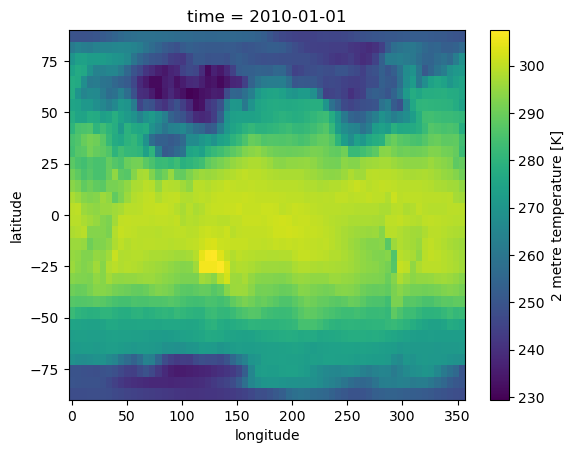

In [17]:
# Print one sample data point from the accessor
accessor['2010-01-01T00']['2m_temperature'].plot(x='longitude', y='latitude')

In [18]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"), 
    # Uncomment the line below if working with multi-level data
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 4, 6)) # Input = 1 sample from time T=0 hours. Output = T+6,+12,+18,+24
    ),    
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=workdir),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours')
)
# data_pipeline

In [19]:
# Uncomment this to view data from the pipeline.
# Experiment with skipping different steps to see the effect on the final data
# data_pipeline['2000-01-06T00']

In [20]:
splits = {
    'train_split': pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours'),
    'valid_split': pyearthtools.pipeline.iterators.DateRange(2018, 2020, interval = '6 hours'),
}

# If you encounter memory problems, set the batch size to a lower number, or 1
# If you encounter CPU / multithreading issues, set num_workers to a lower number, or 0
# 0 is a special number which means 'use the main process', whereas '1' will spawn 1 worker
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_pipeline,
    **splits,
    **{'num_workers': 11, 'batch_size': 8}
)

In [21]:
# If this model doesn't fit on your GPU, reduce the size of the embed_dim to a much lower
# number. This will impact model accuracy but may still produce acceptable outputs.
model = fourcastnext.registered_model.FourCastNextRM(
    pipeline=data_pipeline,       
    lightning_model_params = {'img_size': (64, 32), 
                              'in_channels': 4, # Increase this if using additional data
                              'out_channels': 4, # Increase this if using additional data
                              'embed_dim': 768, 
                              'num_blocks': 4,  
                              'patch_size': (2,2),  # Change this to (4,4) if the GPU memory is exceeded
                              'depth': 12,
                             },
    output='.',
    lead_time=6  # Time delta for autoregressive step
)

Setting up PyTorch Lightning Model
{'img_size': (64, 32), 'in_channels': 4, 'out_channels': 4, 'embed_dim': 768, 'num_blocks': 4, 'patch_size': (2, 2), 'depth': 12}


In [22]:
trainer_configuration = {'precision': '32',                          
                         'checkpointing': [
                             {'monitor': 'train_loss', 'mode': 'min', 
                              'dirpath': '{path}/Checkpoints/Train', 
                              'filename': 'model-{epoch:02d}-{step:02d}', 
                              'every_n_train_steps': 1000, 'save_top_k': 10}, 
                             {'monitor': 'valid_loss', 'mode': 'min', 
                              'dirpath': '{path}/Checkpoints/Valid', 
                              'filename': 'model-{epoch:02d}-{step:02d}-{valid_loss}', 
                              'every_n_train_steps': 5000, 'save_top_k': 10}, 
                             {'monitor': 'epoch', 'mode': 'max', 
                              'dirpath': '{path}/Checkpoints/Epoch', 
                              'filename': 'model-{epoch:02d}', 
                              'save_on_train_epoch_end': True, 
                              'save_top_k': 50}]}

checkpoint_path = workdir 



In [23]:

MAX_EPOCHS = 2  # Suggest training 1 or 2 epochs at first.
                # It is worth experimenting with longer training

trainer = pyearthtools.training.lightning.Train(
    model.lightning_model,  # We train the lightning model not the registered model?
    datamodule,
    path=checkpoint_path,
    trainer_kwargs={'num_sanity_val_steps': 1, 'max_epochs': MAX_EPOCHS, },
    **trainer_configuration
)

In [24]:
# One epoch may take 30-60 minutes. This can be affected by changing the batch size or the patch size.
# trainer.fit()

## Predicting and Evaluating

Once the model has been trained for sufficient time, it can be used to produce predictions. The model must be trained for at least 1000 steps (about 20% of an epoch) before it will create a checkpoint file. This tutorial trains the model for two epochs, but you can interrupt it earlier and resume if you want to look at the performance of the model earlier in the training cycle.

We reload the model using a specific checkpoint file from disk so that we see the same results each time. The models are very sensitive to the normalisation parameters used to train the model, so make sure those are also being used consistently.

We will now compare predicted values to observed values over a specified 24 hour period.

In [25]:
COMPARISON_BASE_TIME = '2011-03-01T00'
COMPARISON_ANALYSIS_TIME = '2011-03-01T06'

In [29]:
# IMPORTANT! Your checkpoints will be in a unique location based on your training!
full_checkpoint_path = workdir + '/Checkpoints/Train/model-epoch=02-step=1000.ckpt'

In [30]:
# If this model doesn't fit on your GPU, reduce the size of the embed_dim to a much lower
# number. This will impact model accuracy but may still produce acceptable outputs.
pmodel = fourcastnext.registered_model.FourCastNextRM(
    pipeline=data_pipeline,      
    ckpt_path = full_checkpoint_path,
    lightning_model_params = {'img_size': (64, 32), 
                              'in_channels': 9, 
                              'out_channels': 9,
                              'embed_dim': 768,
                              'num_blocks': 4,  
                              'patch_size': (2,2),
                              'depth': 12,
                             },
    output='.',
    lead_time=6
)

Setting up PyTorch Lightning Model
{'img_size': (64, 32), 'in_channels': 9, 'out_channels': 9, 'embed_dim': 768, 'num_blocks': 4, 'patch_size': (2, 2), 'depth': 12}


In [ ]:
# %%capture
# IMPORTANT! This cell must be run to produce prediction data. It produces a lot of debugging information, so it has been commented out for display purposes.
prediction = pmodel.run(COMPARISON_BASE_TIME)

analysis_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    # fourcastnext.CropToRectangleSmall(),    
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 4, 6))
    ),
)

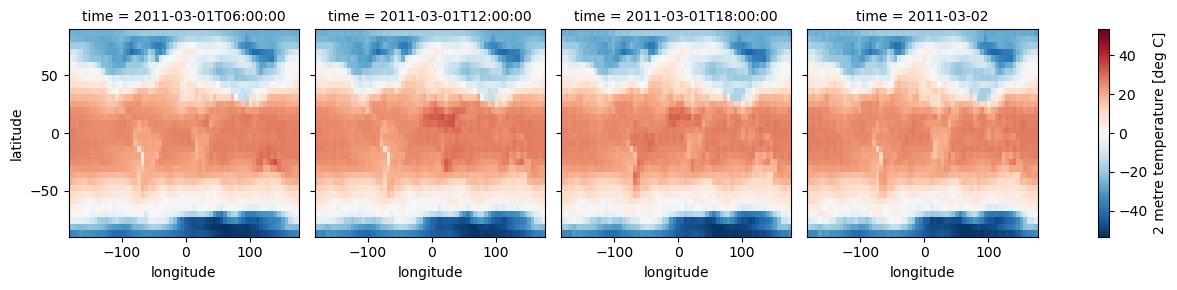

In [17]:
# PLOT MODEL PREDICTIONS
fcst_as_celcius = prediction['2m_temperature'] - 273.15
fcst_as_celcius.attrs["units"] = "deg C"
fcst_as_celcius.plot(x='longitude', y='latitude', col='time', col_wrap=4)

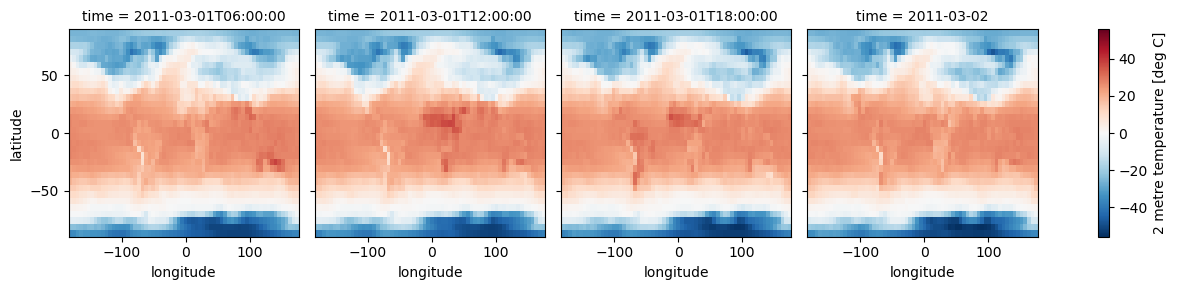

In [18]:
# PLOT ANALYSIS GRIDS (TRUTH)
an_as_celcius = analysis_pipeline[COMPARISON_ANALYSIS_TIME]['2m_temperature'] - 273
an_as_celcius.attrs["units"] = "deg C"
an_as_celcius.plot(x='longitude', y='latitude', col='time', col_wrap=4)

# Things to try next

1. The model may need to train for quite a while to converge. Experiment with additional training.
2. The data includes some additional analysis variables. Try training it on more data and chart out how that affects the training effectiveness as measured by the loss function
3. Try adding some context variables such as time-of-day and time-of-year
4. This notebook doesn't include any comparisons to benchmarks such as a persistence model or an alternative model. Charting skill score comparisons would be very useful.
5. A scorecard of results can also be informative, to see accuracy from multiple perspectives
6. Charting the skill of the model with respect to lead time would also be a useful exercise
7. Use PyTorch Lightning logging to graph training loss with respect to training step to understand how the network is converging

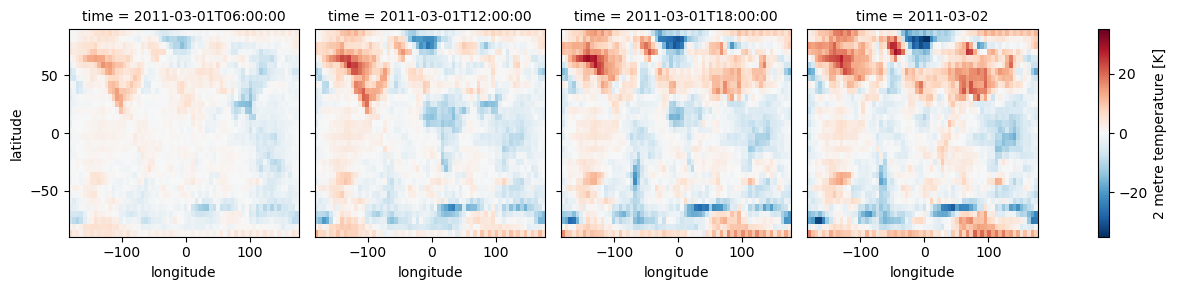

In [19]:
# Plot of Error (remember, this is a simplified model for the tutorial)
# Blue = model is too cold; RED = model is too hot
# Does the model capture the warming of the land as distinct from the ocean? Could a land-sea mask help?
(prediction['2m_temperature'] - analysis_pipeline[COMPARISON_ANALYSIS_TIME]['2m_temperature']).plot(x='longitude', y='latitude', col='time', col_wrap=4)